<a href="https://colab.research.google.com/github/Nouha50215/NLP-Assignment-2/blob/main/model3_cnn_1d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 3: 1D CNN for Sentiment Analysis

1D Convolutional Neural Networks apply **local filters** (kernels) across the token sequence.
Each filter learns to detect a specific n-gram pattern (e.g., 'not good', 'very bad').

## Key properties:
- Filters slide over the sequence capturing local features
- Multiple filter sizes capture patterns of different lengths
- GlobalMaxPooling selects the most prominent feature per filter
- Much faster than RNNs (fully parallelizable)

Architecture: **Embedding → [Conv1D + MaxPool] x3 → GlobalMaxPool → Dense → Output**

In [1]:
# ─────────────────────────────────────────────
# Install dependencies
# ─────────────────────────────────────────────
!pip install nltk gensim tensorflow kagglehub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.4 MB/s eta 0:00:00


In [2]:
# ─────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────
import kagglehub
import pandas as pd
import numpy as np
import re, json
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Gensim for pretrained Word2Vec embeddings
import gensim.downloader as gensim_api

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [3]:
# ─────────────────────────────────────────────
# Load & Clean Data
# ─────────────────────────────────────────────
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
data = pd.read_csv(f"{path}/IMDB Dataset.csv")
data = data.drop_duplicates(subset='review').reset_index(drop=True)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data['clean'] = data['review'].apply(clean_text)
data['label'] = data['sentiment'].map({'positive': 1, 'negative': 0})
print(f"Loaded {len(data)} reviews")

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Loaded 49582 reviews


In [4]:
# ─────────────────────────────────────────────
# CELL 4: Tokenization & Padding
# ─────────────────────────────────────────────
VOCAB_SIZE    = 20000
MAX_LEN       = 256
EMBEDDING_DIM = 100

texts  = data['clean'].tolist()
labels = data['label'].values

# Split data first
texts_temp, texts_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
texts_train, texts_val, y_train, y_val = train_test_split(
    texts_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Fit tokenizer on train only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(texts_train)

# Convert and pad
X_train = pad_sequences(tokenizer.texts_to_sequences(texts_train), maxlen=MAX_LEN, padding='post', truncating='pre')
X_val   = pad_sequences(tokenizer.texts_to_sequences(texts_val),   maxlen=MAX_LEN, padding='post', truncating='pre')
X_test  = pad_sequences(tokenizer.texts_to_sequences(texts_test),  maxlen=MAX_LEN, padding='post', truncating='pre')

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (29748, 256) | Val: (9917, 256) | Test: (9917, 256)


In [5]:
# ─────────────────────────────────────────────
# Load GloVe Word2Vec Embeddings
# ─────────────────────────────────────────────
print("Loading GloVe embeddings...")
word_vectors = gensim_api.load('glove-wiki-gigaword-100')

word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE + 1, EMBEDDING_DIM))
found = 0
for word, idx in word_index.items():
    if idx <= VOCAB_SIZE and word in word_vectors:
        embedding_matrix[idx] = word_vectors[word]
        found += 1

print(f"Coverage: {found}/{min(len(word_index), VOCAB_SIZE)} words found in GloVe")

Loading GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Coverage: 19245/20000 words found in GloVe


In [6]:
# ─────────────────────────────────────────────
# Build Simple 1D CNN (Sequential)
#
# Architecture: Embedding → Conv1D → MaxPool → Conv1D → GlobalMaxPool → Dense
#
# Conv1D(filters, kernel_size):
#   - filters    = number of feature detectors
#   - kernel_size = n-gram window size
#   - activation = ReLU
# ─────────────────────────────────────────────
def build_cnn_simple(filters=128, kernel_sizes=(3, 4, 5),
                     dropout=0.3, learning_rate=1e-3):
    """
    Simple stacked 1D CNN sentiment classifier.
    """
    model = keras.Sequential(name='CNN_Simple')

    # Pretrained GloVe embedding
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE + 1,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True,          # fine-tune embeddings
        name='embedding'
    ))

    # Spatial dropout on embedding output
    model.add(layers.SpatialDropout1D(dropout))

    # Stack Conv1D + MaxPooling layers
    # Each Conv1D scans the sequence with a sliding window of size kernel_size
    for i, k in enumerate(kernel_sizes):
        model.add(layers.Conv1D(
            filters=filters,
            kernel_size=k,
            activation='relu',
            padding='same',       # same padding preserves sequence length
            name=f'conv1d_{i+1}_k{k}'
        ))
        # MaxPooling1D: reduces sequence length by half, keeps strongest signal
        model.add(layers.MaxPooling1D(pool_size=2, name=f'maxpool_{i+1}'))

    # GlobalMaxPooling: takes the max across the entire remaining sequence
    # This gives a fixed-size vector regardless of sequence length
    model.add(layers.GlobalMaxPooling1D(name='global_maxpool'))

    # Fully connected classification head
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid', name='output'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_simple = build_cnn_simple()
cnn_simple.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1_k3 (Conv1D)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2_k4 (Conv1D)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling1D)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3_k5 (Conv1D)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling1D)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_maxpool                  │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,100 (7.63 MB)

 Trainable params: 2,000,100 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ─────────────────────────────────────────────
# Build Multi-Scale CNN (Functional API)
#
# Uses PARALLEL branches with different filter sizes
# to capture patterns at multiple scales simultaneously.
#
# Inspired by the TextCNN paper (Kim, 2014):
#   - Branch 1: kernel_size=2 (bigrams)
#   - Branch 2: kernel_size=3 (trigrams)
#   - Branch 3: kernel_size=5 (5-grams)
# All branches are concatenated and fed to a Dense layer.
# ─────────────────────────────────────────────
def build_cnn_multiscale(filter_sizes=(2, 3, 5), num_filters=128,
                          dropout=0.3, learning_rate=1e-3):
    """
    Multi-scale (TextCNN-style) 1D CNN.
    Processes input with multiple parallel conv branches of different kernel sizes.
    """
    # Input layer
    inp = layers.Input(shape=(MAX_LEN,), name='input')

    # Shared embedding layer
    emb = layers.Embedding(
        input_dim=VOCAB_SIZE + 1,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True,
        name='embedding'
    )(inp)
    emb = layers.SpatialDropout1D(dropout)(emb)

    # ── Parallel branches ──
    branches = []
    for k in filter_sizes:
        # Each branch: Conv1D → GlobalMaxPool
        x = layers.Conv1D(
            filters=num_filters,
            kernel_size=k,
            activation='relu',
            padding='same',
            name=f'conv_k{k}'
        )(emb)
        x = layers.GlobalMaxPooling1D(name=f'pool_k{k}')(x)
        branches.append(x)

    # Concatenate all branches
    merged = layers.Concatenate(name='concat')(branches)
    x = layers.Dense(128, activation='relu')(merged)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='CNN_MultiScale')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_multi = build_cnn_multiscale()
cnn_multi.summary()

Model: "CNN_MultiScale"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 100)  │  2,000,100 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 256, 100)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k2 (Conv1D)    │ (None, 256, 128)  │     25,728 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 256, 128)  │     38,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k5 (Conv1D)    │ (None, 256, 128)  │     64,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k2             │ (None, 128)       │          0 │ conv_k2[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k3             │ (None, 128)       │          0 │ conv_k3[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k5             │ (None, 128)       │          0 │ conv_k5[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 384)       │          0 │ pool_k2[0][0],    │
│ (Concatenate)       │                   │            │ pool_k3[0][0],    │
│                     │                   │            │ pool_k5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     49,280 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,186,085 (8.34 MB)

 Trainable params: 2,186,085 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ─────────────────────────────────────────────
# Train Both CNN Models
# ─────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)
]

BATCH_SIZE = 128
EPOCHS     = 20

print("\n── Training Simple CNN ──")
cnn_simple_hist = cnn_simple.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=1
)

print("\n── Training Multi-Scale CNN ──")
cnn_multi_hist = cnn_multi.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=1
)


── Training Simple CNN ──
Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.6857 - loss: 0.5616 - val_accuracy: 0.8400 - val_loss: 0.3681 - learning_rate: 0.0010
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8511 - loss: 0.3469 - val_accuracy: 0.8690 - val_loss: 0.3038 - learning_rate: 0.0010
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8877 - loss: 0.2740 - val_accuracy: 0.8603 - val_loss: 0.3325 - learning_rate: 0.0010
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9075 - loss: 0.2347 - val_accuracy: 0.8893 - val_loss: 0.2757 - learning_rate: 0.0010
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9185 - loss: 0.2052 - val_accuracy: 0.8917 - val_loss: 0.2672 - learning_rate: 0.0010
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9295 - loss: 0.1828 - val_accuracy: 0.8907 - val_loss: 0.2719 - learning_rate: 0.0010
Epoch 7/20
229/233 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step -

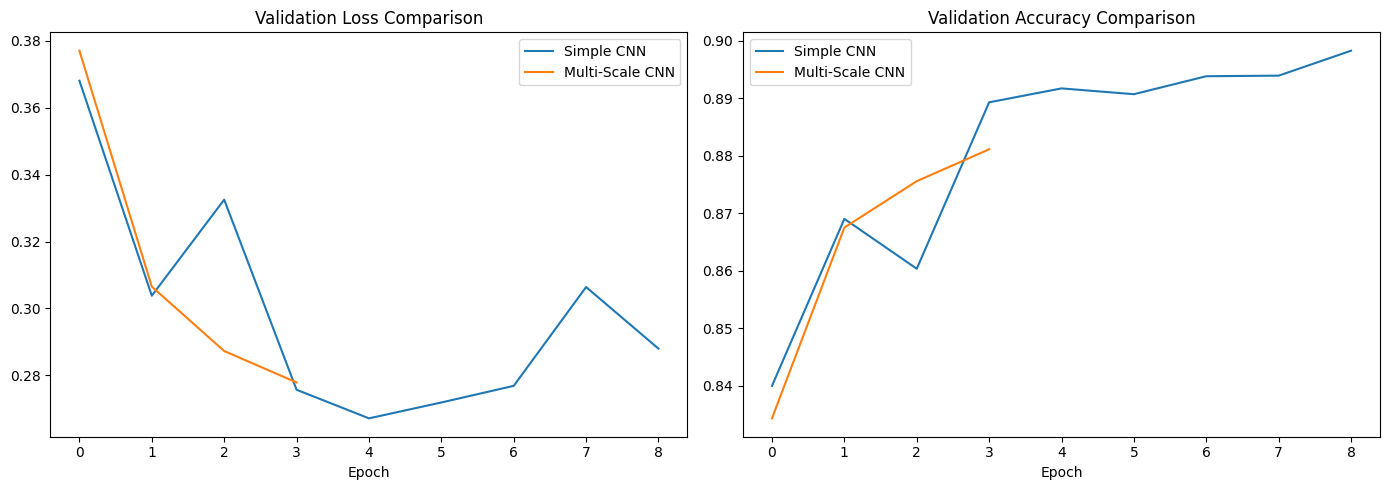

In [9]:
# ─────────────────────────────────────────────
# Training Curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, hist in [('Simple CNN', cnn_simple_hist), ('Multi-Scale CNN', cnn_multi_hist)]:
    axes[0].plot(hist.history['val_loss'],     label=label)
    axes[1].plot(hist.history['val_accuracy'], label=label)

axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()

310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

  CNN_Simple
  Accuracy: 0.8984  |  AUC: 0.9614
              precision    recall  f1-score   support

    negative       0.90      0.89      0.90      4940
    positive       0.89      0.90      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



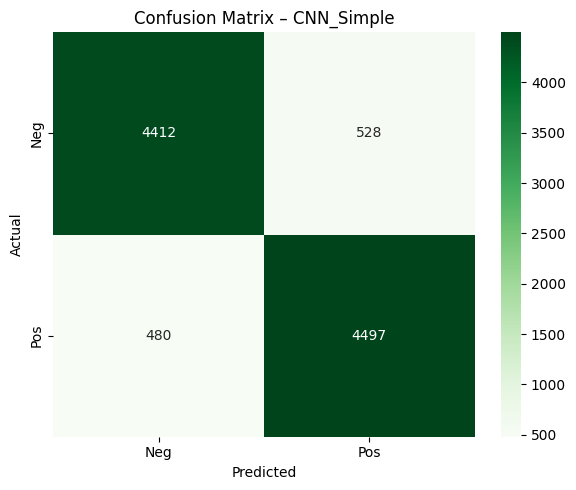

310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

  CNN_MultiScale
  Accuracy: 0.8379  |  AUC: 0.9199
              precision    recall  f1-score   support

    negative       0.86      0.81      0.83      4940
    positive       0.82      0.87      0.84      4977

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917



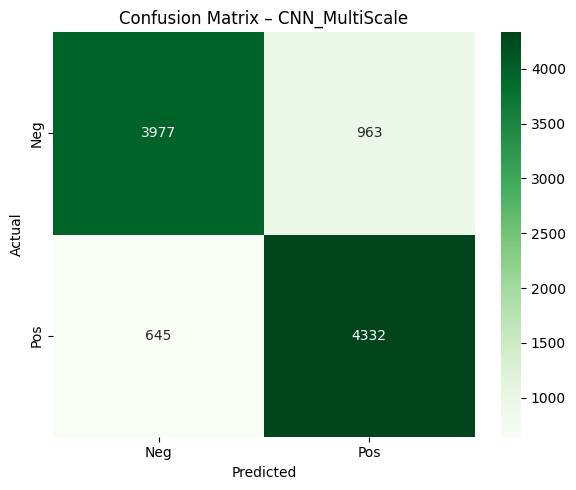

Results saved to results_model3_cnn.json
Models saved!


In [10]:
# ─────────────────────────────────────────────
# Evaluate & Save Results
# ─────────────────────────────────────────────
results = {}

for model_name, model in [('CNN_Simple', cnn_simple), ('CNN_MultiScale', cnn_multi)]:
    y_prob = model.predict(X_test).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, target_names=['negative','positive'])

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"  Accuracy: {acc:.4f}  |  AUC: {auc:.4f}")
    print(report)

    results[model_name] = {
        'test_accuracy': round(float(acc), 4),
        'roc_auc': round(float(auc), 4),
        'classification_report': report
    }

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(f'Confusion Matrix – {model_name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_cm.png', dpi=150)
    plt.show()

results['hyperparameters'] = {
    'vocab_size': VOCAB_SIZE, 'max_len': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'pretrained_embeddings': 'GloVe-100 (gensim)',
    'filters': 128, 'kernel_sizes': [2,3,5],
    'dropout': 0.3, 'batch_size': BATCH_SIZE, 'optimizer': 'Adam'
}

with open('results_model3_cnn.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved to results_model3_cnn.json")

cnn_simple.save('model3_cnn_simple.keras')
cnn_multi.save('model3_cnn_multiscale.keras')
print("Models saved!")

In [11]:
# dowload json files
from google.colab import files

files.download('results_model3_cnn.json')
files.download('model3_cnn_simple.keras')
files.download('model3_cnn_multiscale.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>